---
format:
    html:
        embed-resources: true
---

# Lab: Logistic regression

Author: Dr. H and Gertrude Tiberius Pennington the 4th

Submit a rendered version of this notebook to Canvas

## Demonstration

See the following link for some starter code 

[https://jfh.georgetown.domains/centralized-lecture-content/content/machine-learning/supervised-learning/logistic-regression/share/logistic-regression-stat-models-example/demo.html)

## Part 1: Univariate logistic regression

Consider the following scenario, assume you work at an amusement park as a data scientist!

* NOTE: I know this is a silly toy example but we have to start somewhere! 

![](images/2025-01-27-16-37-06.png)


Assume that a `supervisor` labeld the data as `is_adult` based on visual inspection.  

Toy data of this kind can be found in mass.json

## Load the data

In [1]:
# load the data
import json

with open('mass.json', 'r') as f:
    data = json.load(f)

# convert to pandas dataframe
import pandas as pd

df = pd.DataFrame(data)

# print the dataframe
print(df)

# extract the variables
age = df['x']
weight = df['y']
y = df['is_adult']


    xlabel ylabel  is_adult           x           y
0      age   mass         0    3.000000   48.766263
1      age   mass         0    3.389558   29.945973
2      age   mass         0    3.779116   49.316562
3      age   mass         0    4.168675   41.663606
4      age   mass         0    4.558233   57.909618
..     ...    ...       ...         ...         ...
245    age   mass         1   98.441767  183.863407
246    age   mass         1   98.831325  198.271147
247    age   mass         1   99.220884  185.151908
248    age   mass         1   99.610442  212.768955
249    age   mass         1  100.000000  194.726474

[250 rows x 5 columns]


## Basic univariate curve fitting

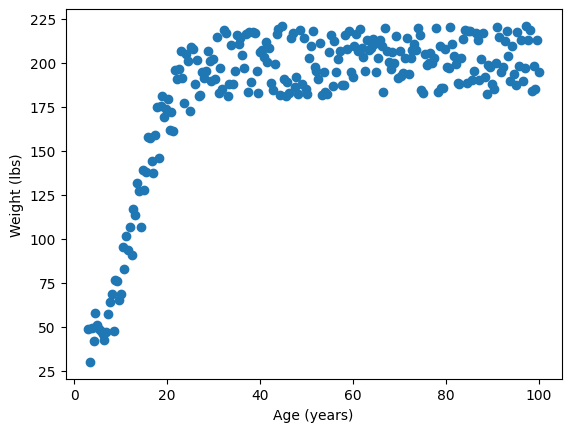

In [2]:
# plot the data
import matplotlib.pyplot as plt
plt.scatter(age, weight)

# axis labels
plt.xlabel('Age (years)')
plt.ylabel('Weight (lbs)')
plt.show()


`IMPORTANT:`  Notice that in this case the y values are not binary, but rather a continuous variable. So this is not a classification problem, but rather a regression problem. 

- **Import necessary library**:
  - Import `scipy.optimize` for optimization functions.

- **Define the sigmoid function**:
  - Implement $\sigma(x) = \frac{1}{1 + e^{-x}}$ , used for modeling non-linear relationships.

- **Define the fitting model**:
  - Create a model with parameters $a, b, c, d$  where $c \cdot \sigma\left(\frac{x - b}{a}\right) + d$  represents the relationship between input $x$  and output $y$ .

- **Define the loss function**:
  - Compute the mean squared error (MSE) between the actual data $y$  and model predictions $\text{model}(x, \text{params})$ .

- **Specify initial guesses**:
  - Use `params0 = [20, 0.1, 200, 0.1]` as starting points for $a, b, c, d$  in optimization.

- **Optimize the objective function**:
  - Use `opt.minimize` with the BFGS method to find parameters $a, b, c, d$  that minimize the loss function based on the data $\text{age}$  and $\text{weight}$ .

- **Print optimization results**:
  - Output the optimized parameters and optimization details.

- **Plot the data and model**:
  - Scatter-plot the actual data ($\text{age}, \text{weight}$ ).
  - Plot the model's predictions over a range of input values as a red curve.

- **Add axis labels and show the plot**:
  - Label the x-axis ($\text{Age (years)}$ ) and y-axis ($\text{Weight (lbs)}$ ), then display the plot.



In [9]:
# INSTRUCTIONS: In this cell you should fit a sigmoid function to the age vs weight data,
# try to do it without normalizing the data, you should be able to choose a suitable inital guess by looking at the plot
# use a suitable parameterization of the sigmoid function
# define a model and a loss function
# optimize the loss function using scipy.optimize.minimize
# plot the data and the results

# INSERT CODE HERE
import numpy as np
from scipy import optimize as opt

# DEFINE SIGMOID FUNCTION
def sigmoid(i):
  return 1/(1+np.exp(-i))

# DEFINE FITTING MODEL
def model(x, params):
  a,b,c,d = params
  y = c * sigmoid((x-b)/a)+d
  return y

# DEFINE LOSS FUNCTION
def loss(params, x, y):
  y_pred = model(x, params)
  return np.mean((y_pred - y)**2)

# OPTIMIZE OBJECTIVE FUNCTION
params0 = [20, 0.1, 200, 0.1]
opt_result = opt.minimize(
  loss,
  params0,
  args = (age, weight),
  method="BFGS"
)


In [ ]:
# DISPLAY OPTMIZATION RESULTS
opt_result

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 135.98094339775295
        x: [ 3.803e+00  1.332e+01  1.731e+02  2.862e+01]
      nit: 19
      jac: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00]
 hess_inv: [[ 9.556e-02 -1.019e-01  1.858e+00 -1.783e+00]
            [-1.019e-01  2.162e-01 -3.040e+00  3.022e+00]
            [ 1.858e+00 -3.040e+00  5.472e+01 -5.296e+01]
            [-1.783e+00  3.022e+00 -5.296e+01  5.189e+01]]
     nfev: 135
     njev: 27

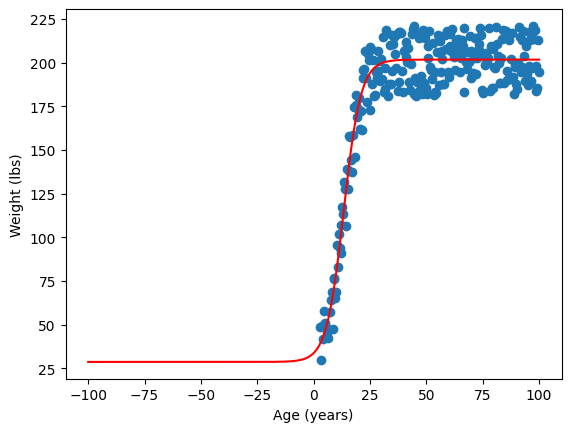

In [20]:
# PLOT DATA AND MODEL
import matplotlib.pyplot as plt
# GENERATE A RANGE OF INPUT AGE VALUES
x_age = np.linspace(-100, 100, 200)
# GENERATE OPTMIZED PREDICTIONS
y_pred = model(x_age, opt_result.x)
plt.scatter(age, weight)
plt.xlabel('Age (years)')
plt.ylabel('Weight (lbs)')
plt.plot(x_age, y_pred, color='red')
plt.show()

## Logistic regression

Now lets use the categorical variable `is_adult` so that we can predict the probability of being an adult based on weight. 


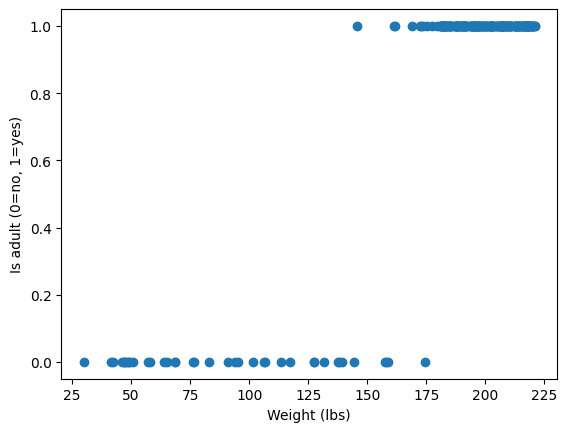

In [353]:
# plot the data
import matplotlib.pyplot as plt
plt.scatter(weight, y)

# axis labels
plt.xlabel('Weight (lbs)')
plt.ylabel('Is adult (0=no, 1=yes)')
plt.show()



### normalize the x data


In [23]:
# INSTRUCTIONS: normalize the weight data using z-score normalization

# INSERT CODE HERE
mu = np.mean(weight)
sd = np.std(weight)
weight_nor = (weight - mu)/sd

## Training validation split

Do an 80-20 split of the data into training and validation sets. 

In [33]:
# INSTRUCTIONS: split the data into training and validation sets, use an 80-20 split and make sure it is a random split

# INSERT CODE HERE
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(
  weight_nor, y,
  test_size=0.2,
  random_state=42,
  shuffle=True
)


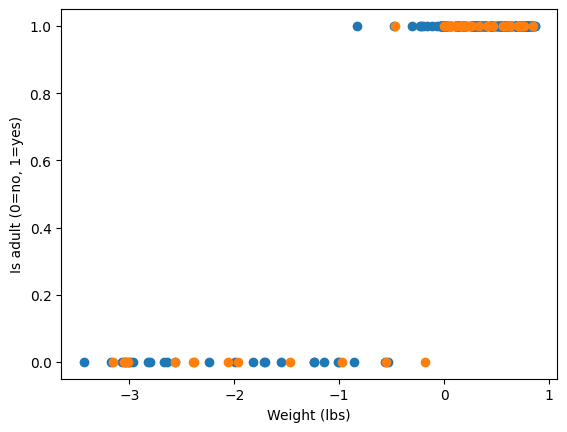

In [35]:
# plot the data
import matplotlib.pyplot as plt
plt.scatter(x_train, y_train)
plt.scatter(x_val, y_val)

# axis labels
plt.xlabel('Weight (lbs)')
plt.ylabel('Is adult (0=no, 1=yes)')
plt.show()

In the following cell you should fit a logistic regression model to the training data. 

`IMPORTANT:` Technically we should use a cross entropy loss function, but we will use the mean squared error loss function for simplicity

- **Import necessary library**:
  - `scipy.optimize` is imported for optimization functions, specifically `opt.minimize` for minimizing the loss function.

- **Define the sigmoid function**:
  - Implements the equation $\sigma(x) = \frac{1}{1 + e^{-x}}$ , a common activation function used in logistic regression.

- **Define the model function**:
  - Takes input data $x$  and parameters $a, b$ , applies the sigmoid function to $ax + b$ , and returns the model's predicted probabilities.

- **Define the loss function**:
  - Calculates the mean squared error (MSE) between the actual $y$  values and the predicted $y$  values from the model.
  - Uses $\text{loss} = \frac{1}{n} \sum (y - \text{model}(x, params))^2$ .

- **Specify initial guess for parameters**:
  - `params0 = [0.1, 0.1]` provides an initial guess for the optimizer for $a$  and $b$ .

- **Optimize the loss function**:
  - `opt.minimize` finds the optimal $a$  and $b$  that minimize the loss function using the BFGS optimization algorithm.
  - Arguments include the loss function, initial parameter guess, and data ($\text{weight}, y$ ).

- **Print the optimization result**:
  - Displays the optimization outcome, including the optimal parameters $a, b$  and other details.

- **Plot the data and the fitted model**:
  - Creates a scatter plot of the data points ($\text{weight}, y$ ).
  - Overlays the model's predicted probabilities using the optimal parameters $a, b$  as a red curve.

- **Label the axes**:
  - Adds labels to the x-axis ($\text{Weight (lbs)}$ ) and y-axis ($\text{Is adult (0=no, 1=yes)}$ ).

- **Show the plot**:
  - Displays the plot with the data and the fitted curve.

- **Print the optimal parameters**:
  - Outputs the optimized values of $a$  and $b$  to the console.


In [ ]:
# INSTRUCTIONS: fit a logistic regression model to the training data
import scipy.optimize as opt

# INSERT CODE HERE
# DEFINE SIGNMOID FUNCTION
def sigmoid(i):
  return 1/(1+np.exp(-i))

# DEFINE MODEL FUNCTION
def model(params, x):
  a, b = params
  y = sigmoid(a * x + b)
  return y

# DEFINE LOSS FUNCTION
def loss(params, x, y):
  y_pred = model(params, x)
  return np.mean((y - y_pred)**2)

# SET INITIAL PARAMATERS
param0 = [0.1, 0.1]

# OPTMIZATION
opt_result = opt.minimize(
  loss,
  param0,
  args = (x_train, y_train), # fit model to traning data as instructed
  method="BFGS"
)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.005111559985681725
        x: [ 7.913e+01  4.024e+01]
      nit: 31
      jac: [-5.184e-06 -5.153e-07]
 hess_inv: [[ 1.403e+06  7.152e+05]
            [ 7.152e+05  3.655e+05]]
     nfev: 114
     njev: 38


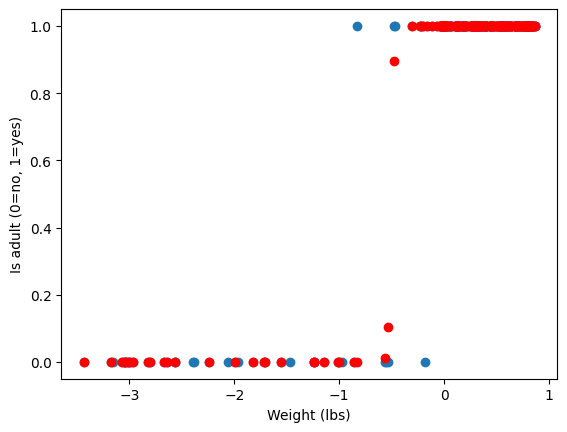

optimal parameters:  [79.12843949 40.23612081]


In [50]:
# PRINT OPTMIZATION RESULT
print(opt_result)

# PLOT OPTIMIZATION RESULT
plt.scatter(weight_nor, y)
y_pred = model(opt_result.x, x_train)
plt.scatter(x_train, y_pred, color='red')
plt.xlabel('Weight (lbs)')
plt.ylabel('Is adult (0=no, 1=yes)')
plt.show()

# PRINT OPTMIZATION PARAMETERS
print('optimal parameters: ', opt_result.x)

## Statsmodels

now lets repeat with statsmodel

In [57]:
# INSTRUCTIONS: fit a logistic regression model to the training data using statsmodels, output the summary of the model and a plot

# INSERT CODE HERE
import statsmodels.api as sm

# ADD INTERCEPT
x_train_const = sm.add_constant(x_train)
# FIT THE LOGISTIC MODEL
logit_model = sm.Logit(y_train, x_train_const)
result = logit_model.fit()


Optimization terminated successfully.
         Current function value: 0.024255
         Iterations 11


In [58]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:               is_adult   No. Observations:                  200
Model:                          Logit   Df Residuals:                      198
Method:                           MLE   Df Model:                            1
Date:                Sat, 31 Jan 2026   Pseudo R-squ.:                  0.9387
Time:                        10:26:01   Log-Likelihood:                -4.8510
converged:                       True   LL-Null:                       -79.156
Covariance Type:            nonrobust   LLR p-value:                 3.488e-34
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3309      1.739      3.066      0.002       1.923       8.739
y              8.7016      2.979      2.921      0.003       2.862      14.541

Possibly complete quasi-separation: A fraction 0.51

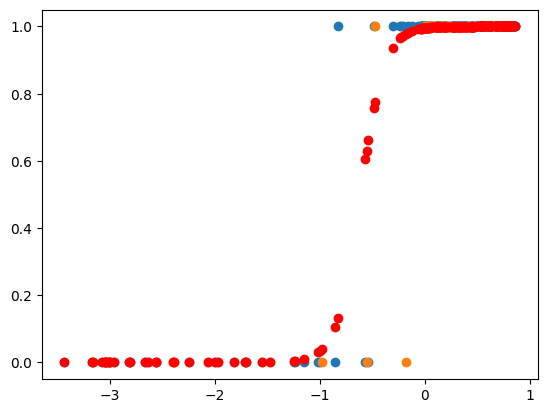

In [59]:
# plot the data and the results
# ADD INTERCEPT ON x_val
x_val_const = sm.add_constant(x_val)

plt.scatter(x_train, y_train)
plt.scatter(x_val, y_val)
plt.plot(x_train, result.predict(x_train_const), "ro")
plt.plot(x_val, result.predict(x_val_const), "ro")
plt.show()


# Part-3: Multi-class logistic regression

A logistic regressor is inherently a binary classifier, however, it can be extended to multi-class classification.

In the multiclass case, the training algorithm uses a one-vs.-all (OvA) scheme, rather than the “true” multinomial LR.

**OVA (One-vs-All)** and **OVR (One-vs-Rest)** are the same concept under different names. Both refer to a strategy used in multiclass classification problems where a classifier is trained for each class against all the other classes combined. Here's an example:


![](images/2025-01-27-16-55-43.png)



We will apply logistic regression to the digits dataset, which is a simplified version of the 28x28 MNIST dataset. 

The digits dataset is a collection of 1797 8x8 images of digits. 

target:  8


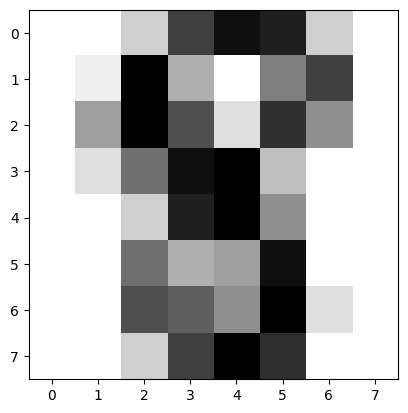

In [2]:
## import digits

import sklearn.datasets as datasets

digits = datasets.load_digits()

# visualize a particular digit

import matplotlib.pyplot as plt
import numpy as np
random_index = np.random.choice(len(digits.data))
print("target: ", digits.target[random_index])

plt.imshow(digits.images[random_index], cmap=plt.cm.gray_r, interpolation='nearest')
plt.show()


In the case of the digits dataset, we have 10 classes, so we will need to train 10 logistic regressors (Sklearn will do this for us). 

Our model input is a vector X formed by flattening the 8x8 image into a 64-dimensional vector.

Our corresponding target is a one-hot encoded vector y of length 10, where each element is 0 or 1, depending on whether the digit is that class.

in the following code, we will split the data into training and validation sets. 

We will use 80% of the data for training and 20% for validation. 

In [22]:
# INSTRUCTIONS: in this cell you should split the data into training and validation sets. Make sure it is a random split.

# split the data into training and validation sets

# 80-20 split

# INSERT CODE HERE

import numpy as np
from sklearn.model_selection import train_test_split

# SPLIT DATA TO TRAINING AND VALIDATION SETS
x_train, x_val, y_train, y_val = train_test_split(
  digits.data, digits.target,
  test_size = 0.2,
  random_state=42
)

The following code cell should train a logistic regression model using the One-vs-Rest classification strategy and evaluates its performance over a range of regularization strengths ($\text{L2 penalty}$) (i.e. hyperparameter-tuning). The model is trained and validated on given datasets ($x_{\text{train}}, y_{\text{train}}, x_{\text{val}}, y_{\text{val}}$). For each value of the regularization strength ($C = 1/\text{L2}$), the model is fitted, and predictions are made for both the training and validation datasets. The training and validation accuracies, along with the F1 scores (macro-averaged), are computed to assess the model's performance. The results, including accuracies and F1 scores, are stored and plotted to visualize how the model's performance changes with different regularization strengths, providing insights into the trade-off between underfitting and overfitting.

In [ ]:
# INSERT CODE HERE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# DEFINE ONE-VS-REST CLASSIFICATION MODEL
def ovs_model(l2):

  # CREATE MODEL
  model = LogisticRegression(
    penalty='l2',
    C=1/l2,
    multi_class='ovr',
    solver='lbfgs',
    max_iter=1000
  )

  # TRAIN MODEL
  model.fit(x_train, y_train)

  # MAKE PREDICTIONS
  y_train_pred = model.predict(x_train)
  y_val_pred = model.predict(x_val)

  # EVALUATIONS
  metrics = {
    'train_accuracy': accuracy_score(y_train, y_train_pred),
    'validation_accuracy': accuracy_score(y_val, y_val_pred),
    'train_f1': f1_score(y_train, y_train_pred, average='macro'),
    'validation_f1': f1_score(y_val, y_val_pred, average='macro')
  }

  # RETURN OUTPUT
  return metrics


In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd

# FIT MODEL WITH MULTIPLE STRENGTH VALUES
ovs_model_result = []
for l2 in [0.0001, 0.001, 0.01, 0.1, 1, 10, 25, 50, 75, 100]:
  C = 1/l2
  train_accuracy = ovs_model(l2)['train_accuracy']
  val_accuracy = ovs_model(l2)['validation_accuracy']
  train_f1 = ovs_model(l2)['train_f1']
  val_f1 = ovs_model(l2)['validation_f1']

  # SAVE THE RESULT
  ovs_model_result.append({
    '1/C': 1/C,
    'train_accuracy': train_accuracy,
    'val_accuracy': val_accuracy,
    'train_f1': train_f1,
    'val_f1': val_f1
  })

  # PRINT RESULTS
  print(f'1/C={1/C}, train_accuracy={train_accuracy}, val_accuracy={val_accuracy}, train_f1={train_f1}, val_f1={val_f1}')

  ovs_model_df = pd.DataFrame(ovs_model_result)

1/C=0.0001, train_accuracy=1.0, val_accuracy=0.9222222222222223, train_f1=1.0, val_f1=0.9213106754798032
1/C=0.001, train_accuracy=0.9993041057759221, val_accuracy=0.9444444444444444, train_f1=0.9993279433487816, val_f1=0.9435497076967492
1/C=0.01, train_accuracy=0.9993041057759221, val_accuracy=0.95, train_f1=0.9993279433487816, val_f1=0.9488201043177833
1/C=0.1, train_accuracy=0.9993041057759221, val_accuracy=0.9555555555555556, train_f1=0.9993279433487816, val_f1=0.9545872178059442
1/C=1.0, train_accuracy=0.9965205288796103, val_accuracy=0.9666666666666667, train_f1=0.9966018294649596, val_f1=0.9660902353180036
1/C=10.0, train_accuracy=0.9944328462073765, val_accuracy=0.9638888888888889, train_f1=0.994485079669748, val_f1=0.9643094870930768
1/C=25.0, train_accuracy=0.988865692414753, val_accuracy=0.9666666666666667, train_f1=0.9888719926454984, val_f1=0.9677538665982397
1/C=50.0, train_accuracy=0.9860821155184412, val_accuracy=0.9666666666666667, train_f1=0.9861476412157982, val_f1=

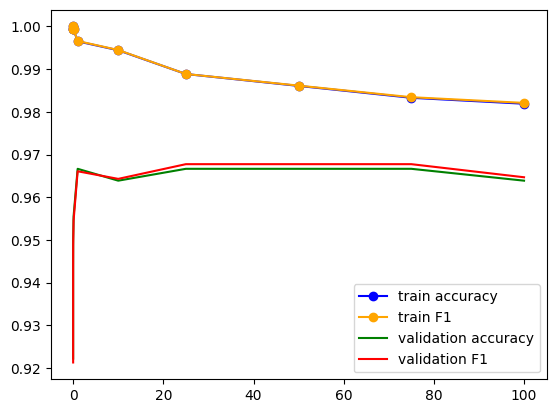

In [57]:
# PLOT THE RESULT
plt.plot(ovs_model_df['1/C'], ovs_model_df['train_accuracy'], marker='o', color='blue', label='train accuracy')
plt.plot(ovs_model_df['1/C'], ovs_model_df['train_f1'], marker='o', color='orange', label='train F1')
plt.plot(ovs_model_df['1/C'], ovs_model_df['val_accuracy'], color='green', label='validation accuracy')
plt.plot(ovs_model_df['1/C'], ovs_model_df['val_f1'], color='red', label='validation F1')
plt.legend()
plt.show()

In [58]:
# INSTRUCTIONS: select the optimal value of C and retrain the model

# INSERT CODE HERE
# Select optimal 1/C=25 (C=1/25) and retrain the model

model = LogisticRegression(
    penalty='l2',
    C=1/25,
    multi_class='ovr',
    solver='lbfgs',
    max_iter=1000
  )

  # TRAIN MODEL
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.04
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'ovr'


In [59]:
# in the following cells you should report the performance of the model on the training and validation sets

from sklearn.metrics import classification_report, confusion_matrix
def report(model, x, y):
    y_pred = model.predict(x)
    print(classification_report(y, y_pred))

    # confusion matrix
    print(confusion_matrix(y, y_pred))


In [60]:
report(model, x_train, y_train)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       145
           1       0.97      0.99      0.98       154
           2       0.99      1.00      1.00       144
           3       0.99      0.99      0.99       149
           4       0.99      0.99      0.99       135
           5       0.99      0.99      0.99       135
           6       1.00      0.99      1.00       146
           7       1.00      1.00      1.00       145
           8       0.97      0.95      0.96       144
           9       0.99      0.98      0.98       140

    accuracy                           0.99      1437
   macro avg       0.99      0.99      0.99      1437
weighted avg       0.99      0.99      0.99      1437

[[145   0   0   0   0   0   0   0   0   0]
 [  0 152   0   0   0   0   0   0   1   1]
 [  0   0 144   0   0   0   0   0   0   0]
 [  0   0   0 148   0   0   0   0   1   0]
 [  0   0   0   0 134   0   0   0   1   0]
 [  0   0   0   0   0 134 

In [61]:
report(model, x_val, y_val)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      1.00      0.97        28
           2       0.97      1.00      0.99        33
           3       1.00      0.97      0.99        34
           4       1.00      0.98      0.99        46
           5       0.92      0.94      0.93        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.93      0.93      0.93        30
           9       0.95      0.93      0.94        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360

[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  1  0  0 45  0  0  0  0  0]
 [ 0  0  1  0  0 44  1  0  0  1]
 [ 0  0  0  0  0  1 34  0  0  0]
 [ 0  0  0

**Written Assignment**:  In your own words, describe the previous code cell outputs and what they mean.

`INSERT TEXT HERE`